<h1 style="color:red">Power Transformer</h1>

<h2> ---------- Box Cox Transform   ---------------  ..    --------------- Yeo-Johnson Transform ---------</h2>

<div style="display:flex; flex-direction:row">
    <img style="width:500px; margin-right:20px" src="images/Box Cox transform.png">
    <img style="width:500px" src="images/Yeo-Johnson Transform.jpeg">
</div>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot 
import seaborn as sns 

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# as y_train contains continuous (float) values,
# we cant use 'LogisticRegression' as it is a classifier that expects discrete class labels (like 0, 1, 2) (int).
from sklearn.linear_model import LinearRegression

# If y is genuinely continuous(float), Then skip 'LogisticRegression' + 'accuracy_score' entirely use r2_score instead
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.shape

(1030, 9)

In [5]:
df.isnull().sum()    # no null values

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [6]:
df.describe()     # no column has negative value, but some has 0 as it's min value

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
X = df.iloc[:, :8]
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape

((721, 8), (309, 8))

<h2 style="color:blue"> Without Transformation</h2>

In [8]:
# Applying Regression without applying Transformation
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2_score(y_test, y_pred)

0.6352987285077925

In [9]:
# checking via Cross_val_score 
lr = LinearRegression() 

np.mean(cross_val_score(lr, X, y, scoring='r2', cv=5))

np.float64(0.4609940491662865)

<h2 style="color:blue"> Plotting PDF and QQ plot</h2>

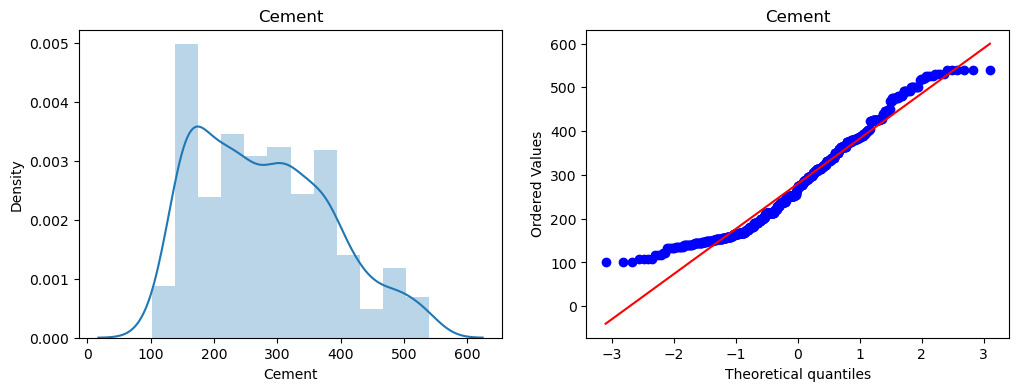

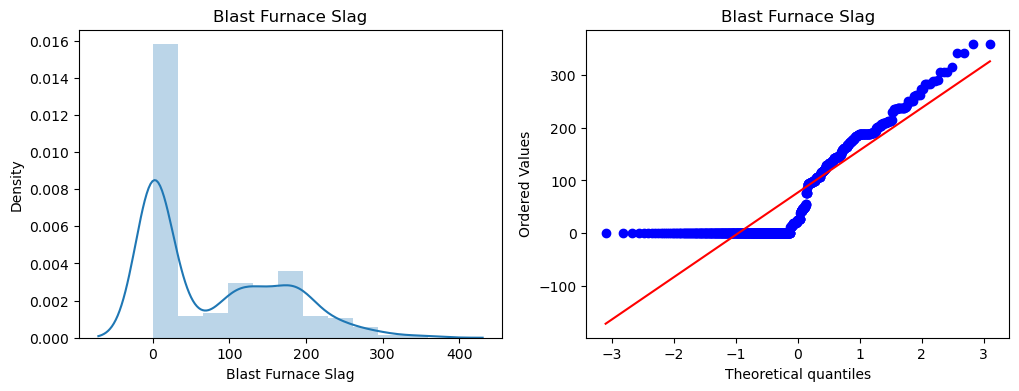

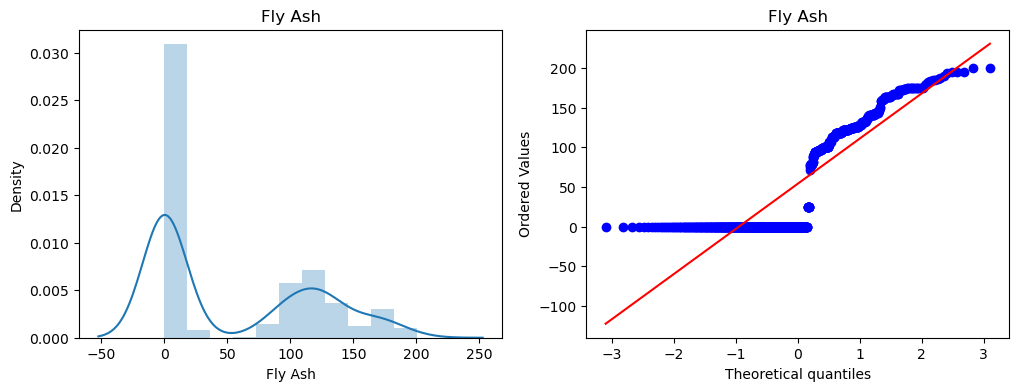

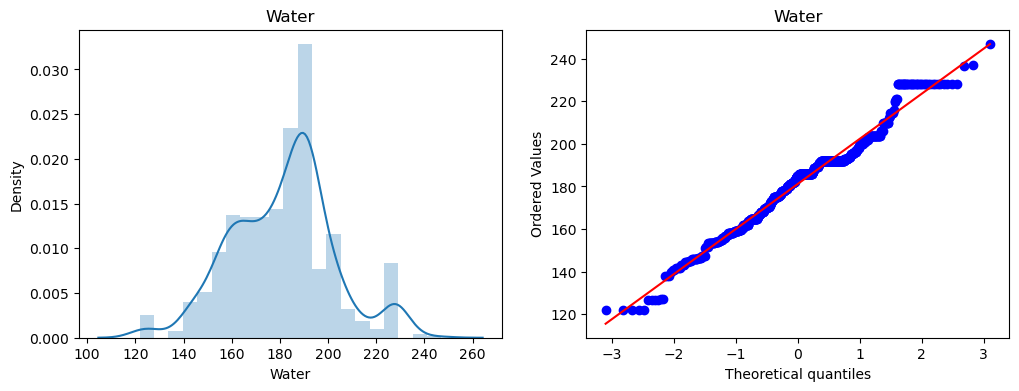

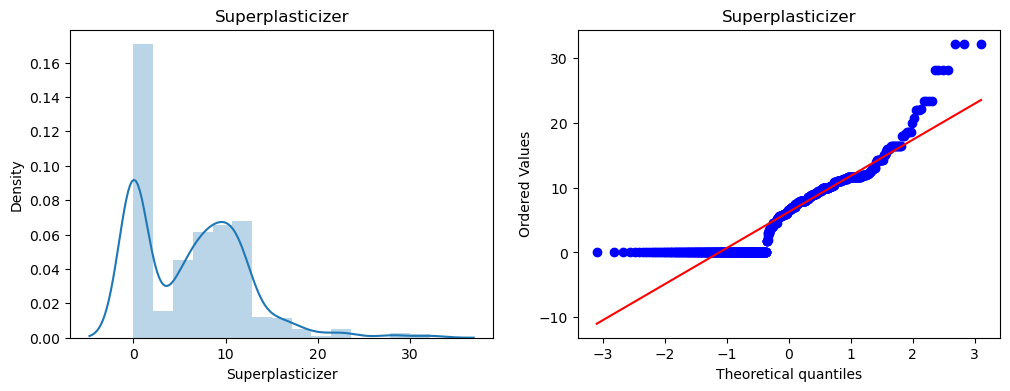

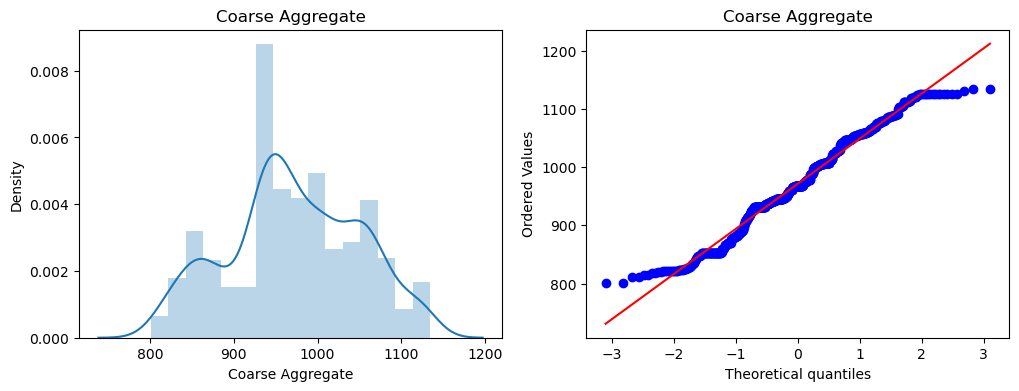

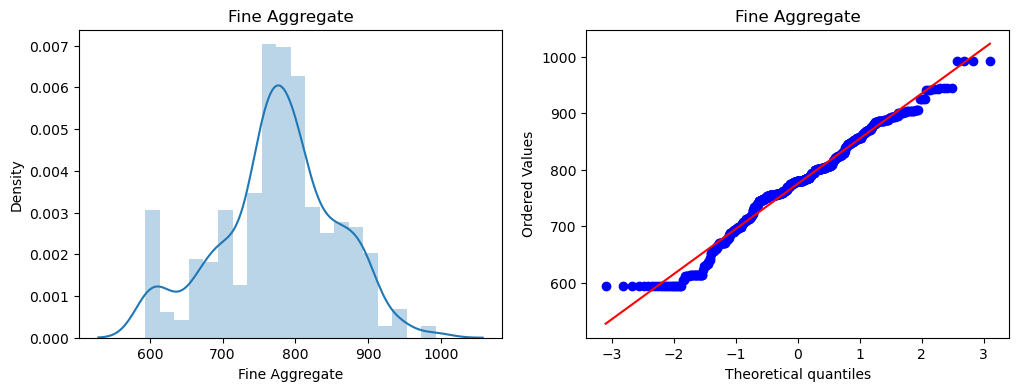

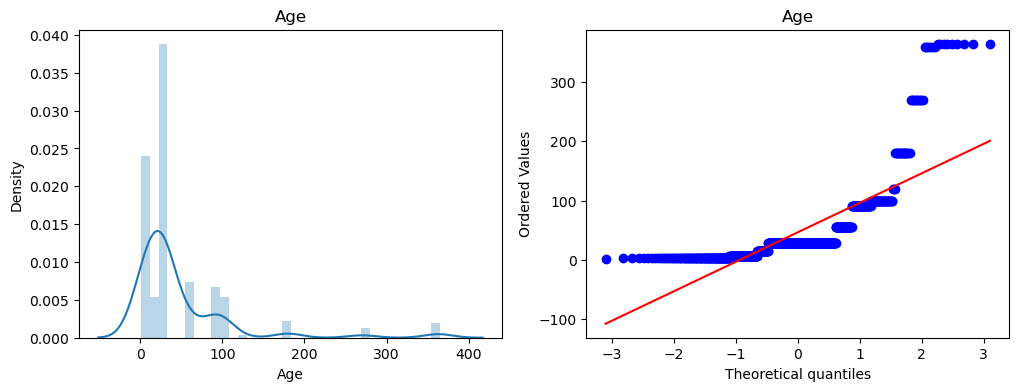

In [10]:
for col in X_train.columns: 
    pyplot.figure(figsize=(12,4))
    pyplot.subplot(121)
    sns.histplot(x=X_train[col], stat='density',alpha=0.3, edgecolor=None)              # alpha=0.4,   Controls transparency,  Range: 0 to 1
    # stat='density' → puts histogram on probability scale
    # linewidth=0 or edgecolor=None to hide the lines in the bars.
    sns.kdeplot(x=X_train[col]) 
    pyplot.title(col)
    
    pyplot.subplot(122)
    stats.probplot(x=X_train[col], dist='norm', plot=pyplot)
    pyplot.title(col)
    pyplot.show()

<h2 style="color:blue"> Box Cox Transform</h2>

In [11]:
# Applying Box Cox Transform 

# Box-Cox requires input data to be strictly positive, while Yeo-Johnson supports both positive or negative data.
pt = PowerTransformer(method='box-cox')
# method : {‘yeo-johnson’, ‘box-cox’}, default=’yeo-johnson’
# standardize : bool, default=True,    unit-variance normalization to the transformed output, means bydefault StandardScaler is applied to internally.

X_train_tnf = pt.fit_transform(X_train + 0.000001)      # adding a small value to handle zeroes in X_train
X_test_tnf = pt.transform(X_test + 0.000001)     

# Making a dataframe for the lambda(λ) values of each of the column 
lambda_vals = pd.DataFrame({'cols':X_train.columns, 'box-cox lambda':pt.lambdas_})
lambda_vals

,cols,box-cox lambda
0,Cement,0.183828
1,Blast Furnace Slag,0.028478
2,Fly Ash,-0.040397
3,Water,0.925279
4,Superplasticizer,0.106875
5,Coarse Aggregate,1.144747
6,Fine Aggregate,1.771619
7,Age,0.041458


<h2 style="color:blue"> Linear Regression</h2>

In [12]:
# Applying Linear Regression on transformed data 
lr = LinearRegression() 

lr.fit(X_train_tnf, y_train)

y_pred = lr.predict(X_test_tnf)

r2_score(y_test, y_pred)

0.8170870467897093

In [13]:
# using cross_val_score 
pt = PowerTransformer(method='box-cox')
X_tnf = pt.fit_transform(df.iloc[:, :8] + 0.000001)
y = df.iloc[:, -1]  
lr = LinearRegression()

np.mean(cross_val_score(lr, X_tnf, y, scoring='r2', cv=10))

np.float64(0.6466764736216227)

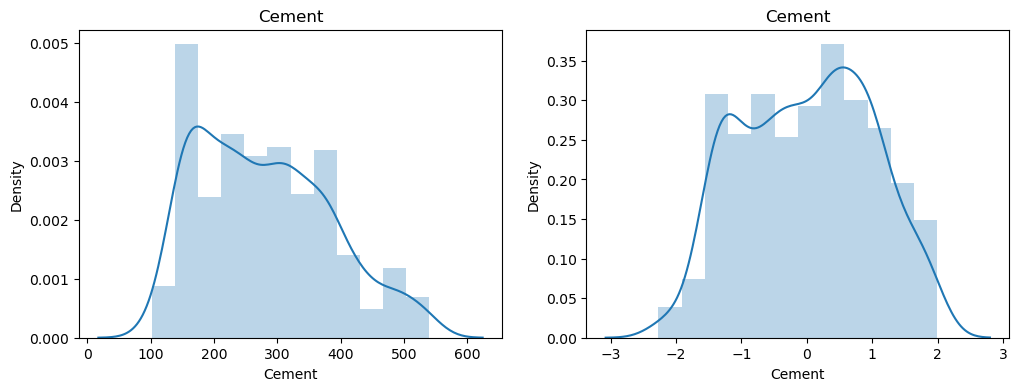

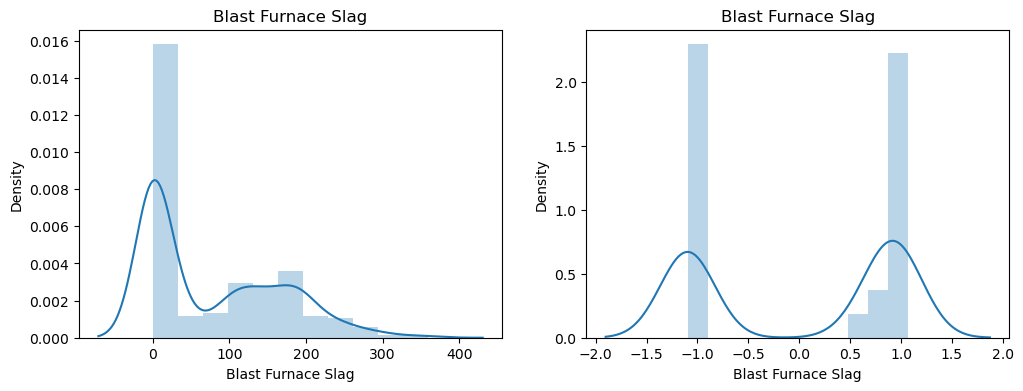

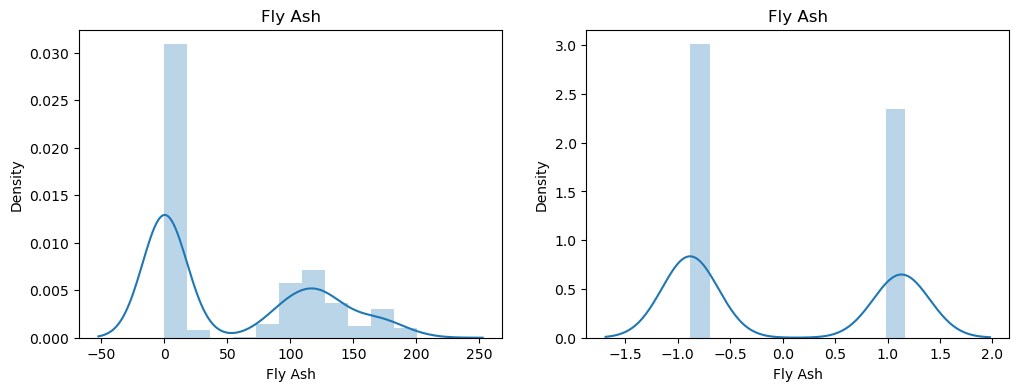

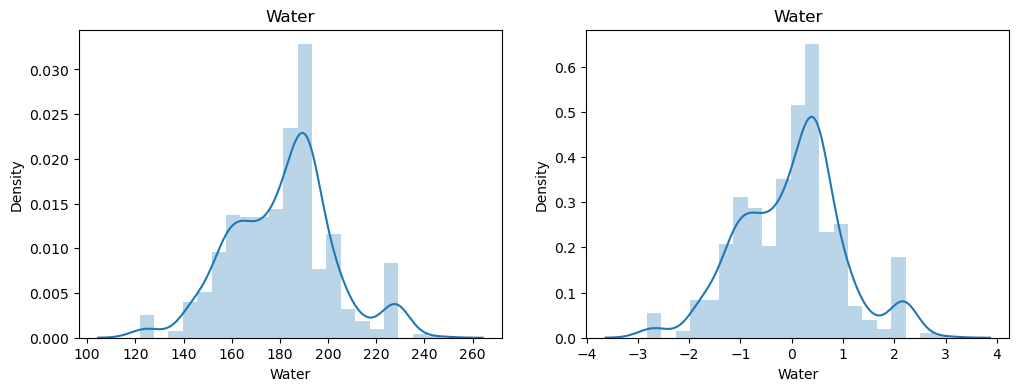

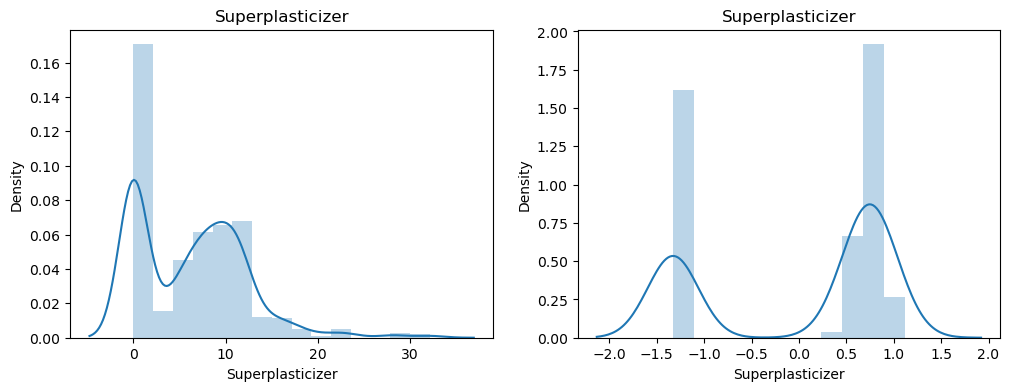

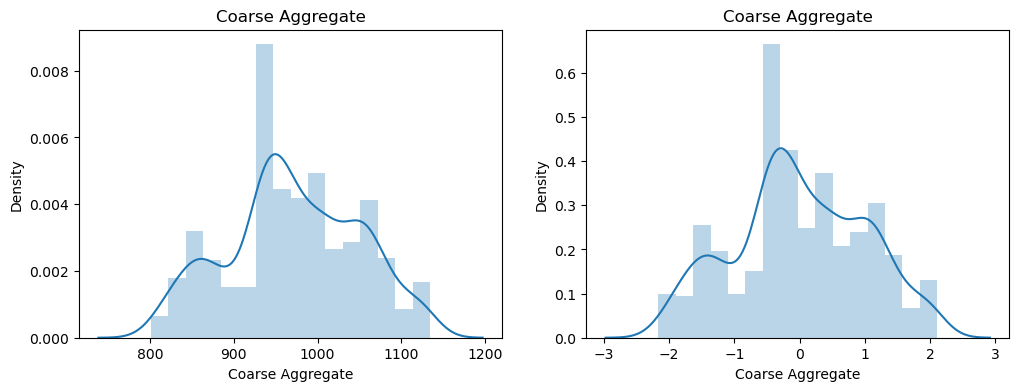

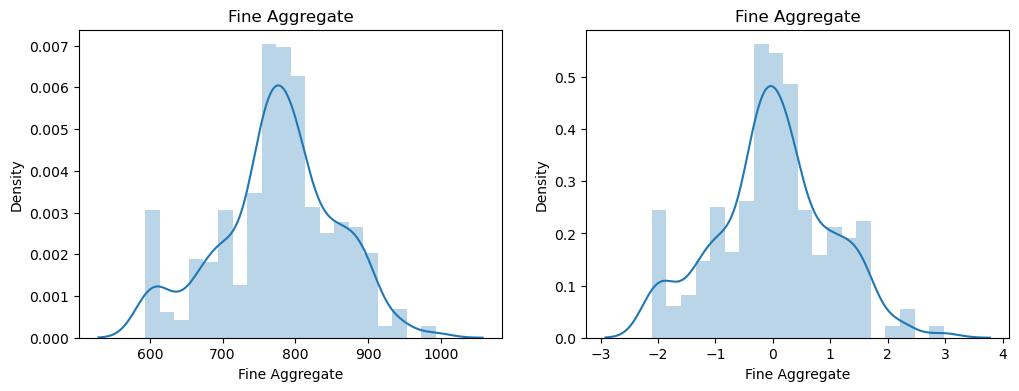

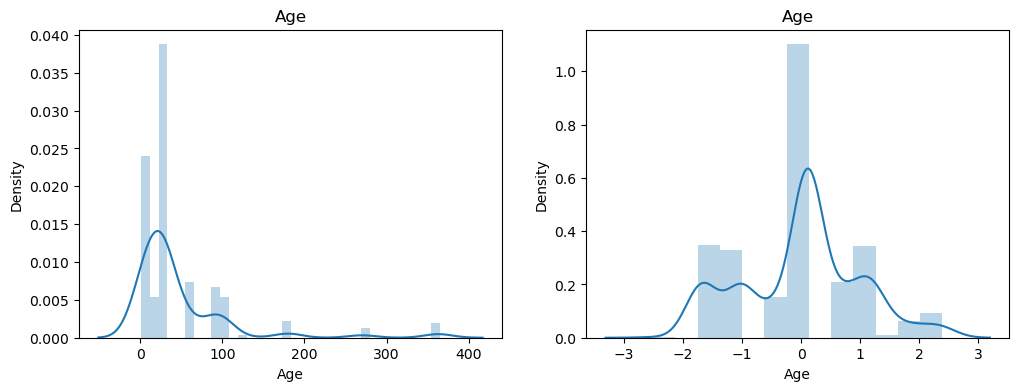

In [14]:
# Before and After Comparison of Box-Cox Plot 
X_train_tnf = pd.DataFrame(X_train_tnf, columns=X_train.columns) 

for cols in X_train.columns: 
    pyplot.figure(figsize=(12,4))
    pyplot.subplot(121)      # before transformation
    sns.histplot(x=X_train[cols], stat='density', alpha=0.3, edgecolor=None)
    sns.kdeplot(x=X_train[cols])
    pyplot.title(cols)
    
    pyplot.subplot(122)      # After transformation
    sns.histplot(x=X_train_tnf[cols], stat='density', alpha=0.3, edgecolor=None)
    sns.kdeplot(x=X_train_tnf[cols])
    pyplot.title(cols)
    pyplot.show()

<h2 style="color:blue"> Yeo-Johnson Transform</h2>

In [15]:
# Apply Yeo-Johnson transform 
pt2 = PowerTransformer()    # by-default - yeo-johnson

X_train_yeo = pt2.fit_transform(X_train)
X_test_yeo = pt2.transform(X_test) 

lr = LinearRegression()

lr.fit(X_train_yeo, y_train)

y_pred = lr.predict(X_test_yeo)

print("r2_score :", r2_score(y_test, y_pred))

lambda_vals_yeo = pd.DataFrame({'cols':X_train.columns, 'yeo-johnson lambdas':pt2.lambdas_})
lambda_vals_yeo

r2_score : 0.8250136884487966


,cols,yeo-johnson lambdas
0,Cement,0.181196
1,Blast Furnace Slag,0.028011
2,Fly Ash,-0.165526
3,Water,0.924736
4,Superplasticizer,0.286946
5,Coarse Aggregate,1.145007
6,Fine Aggregate,1.772672
7,Age,-0.005485


In [16]:
# cross_val_score 
pt2 = PowerTransformer()
X_yeo = pt2.fit_transform(df.iloc[:, :8])
y = df.iloc[:, -1]

lr = LinearRegression()

np.mean(cross_val_score(lr, X_yeo, y, scoring='r2', cv=10))

np.float64(0.658654862909492)

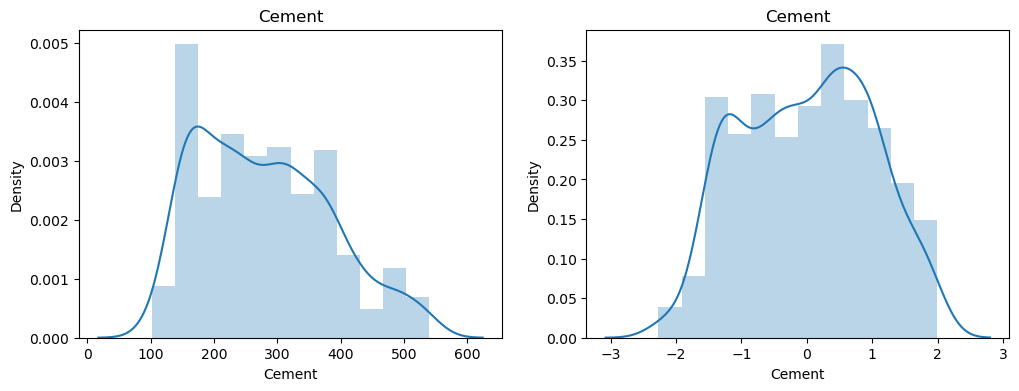

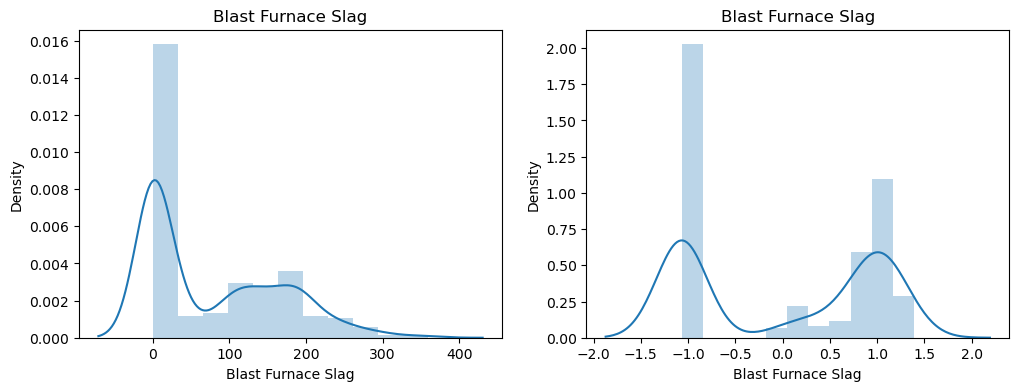

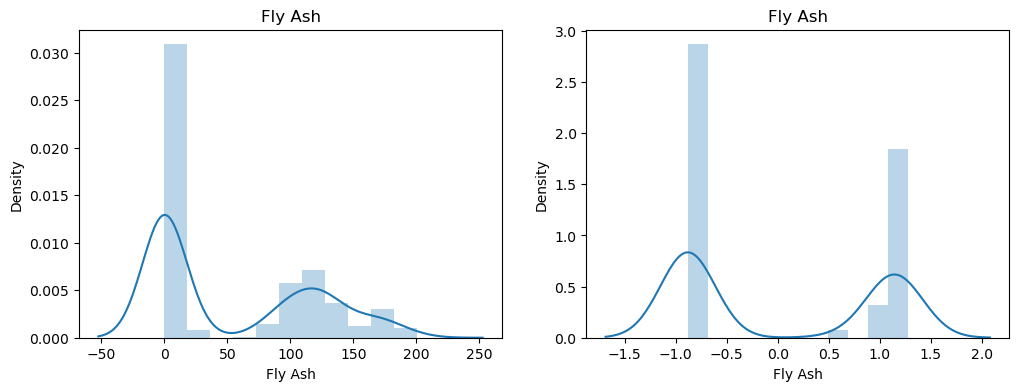

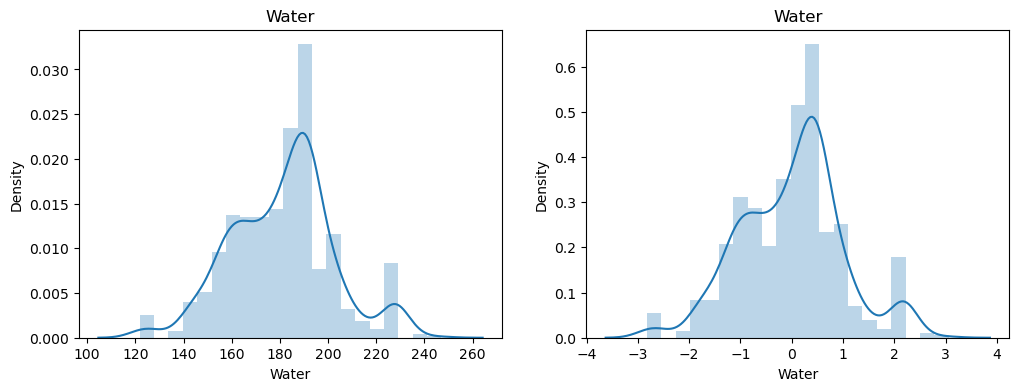

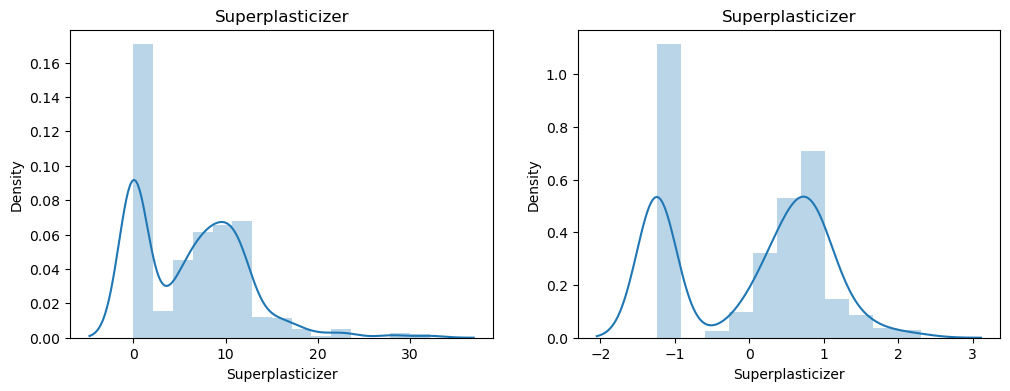

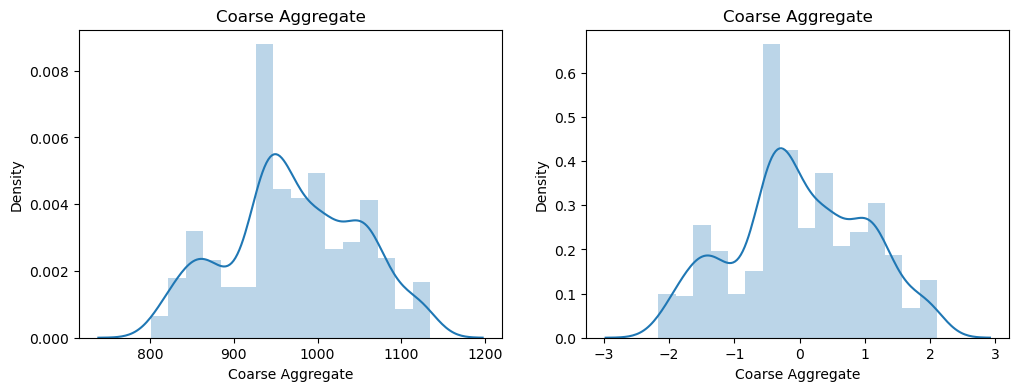

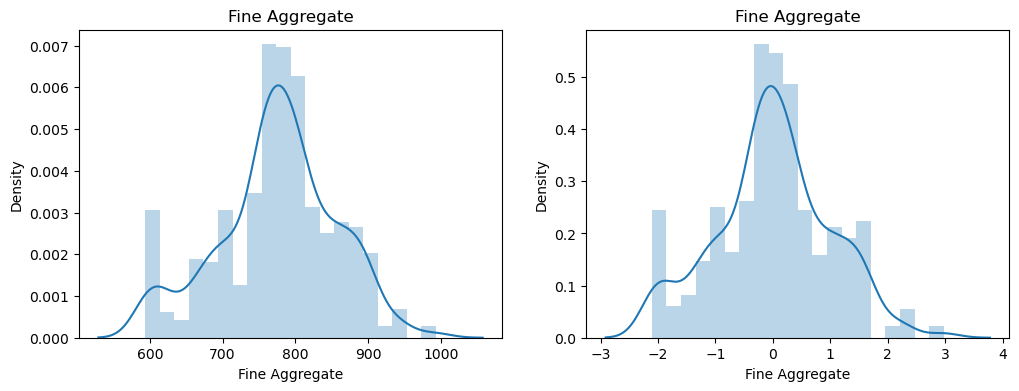

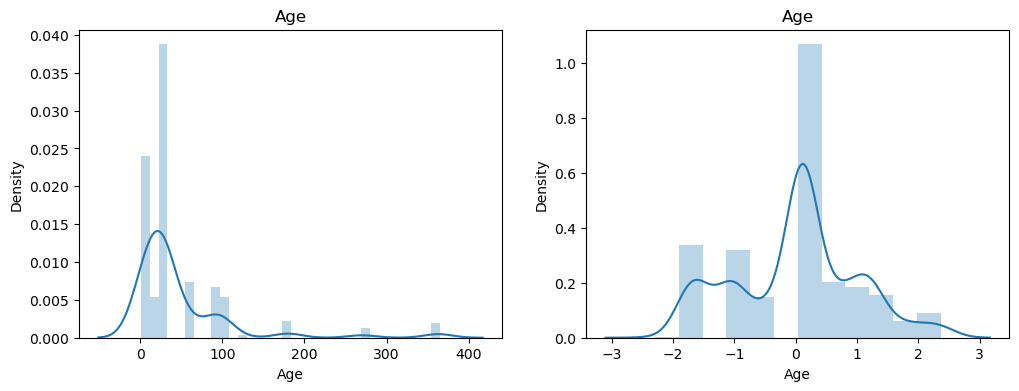

In [17]:
# Analysing Before and After Yeo-Johnson Transformation
X_train_yeo = pd.DataFrame(X_train_yeo, columns=X_train.columns)

for cols in X_train.columns:
    pyplot.figure(figsize=(12,4))
    pyplot.subplot(121)
    sns.histplot(x=X_train[cols], stat='density', alpha=0.3, linewidth=0)
    sns.kdeplot(x=X_train[cols])
    pyplot.title(cols)
   
    pyplot.subplot(122)
    sns.histplot(x=X_train_yeo[cols], stat='density', alpha=0.3, linewidth=0)
    sns.kdeplot(x=X_train_yeo[cols])
    pyplot.title(cols)
    pyplot.show()

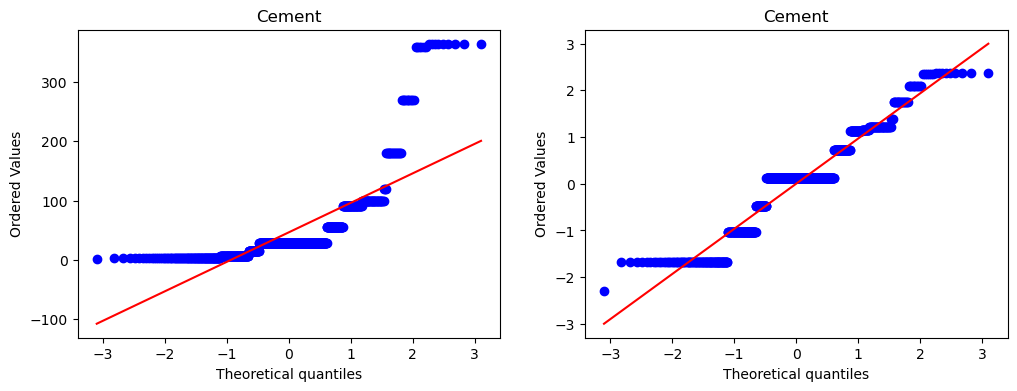

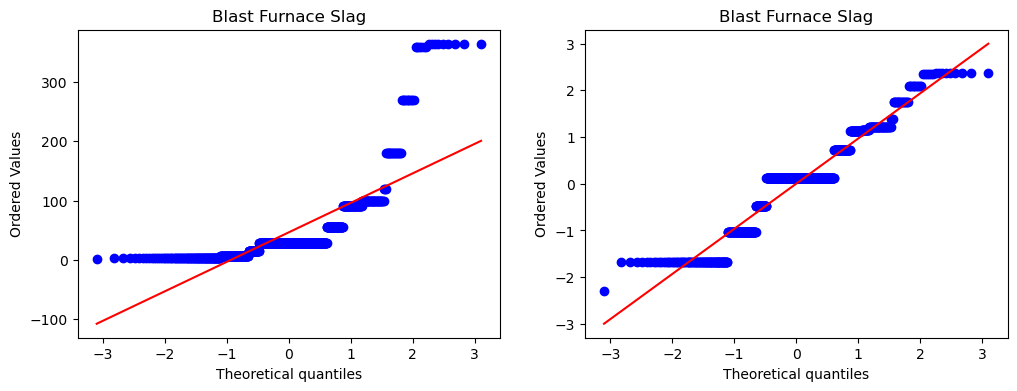

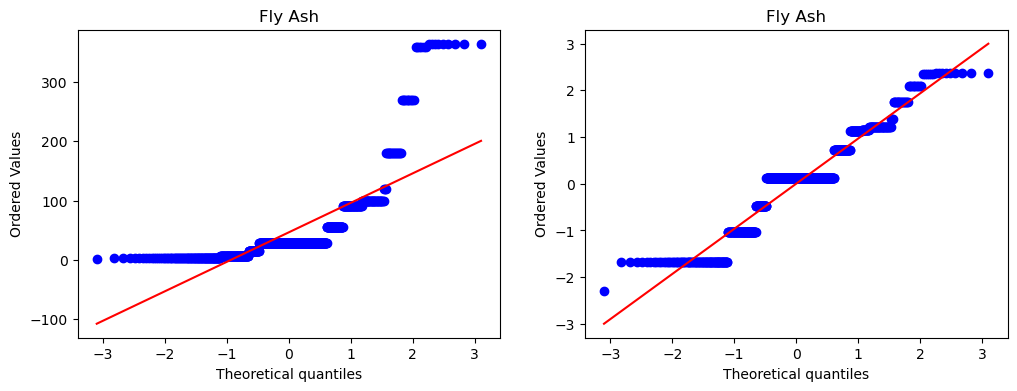

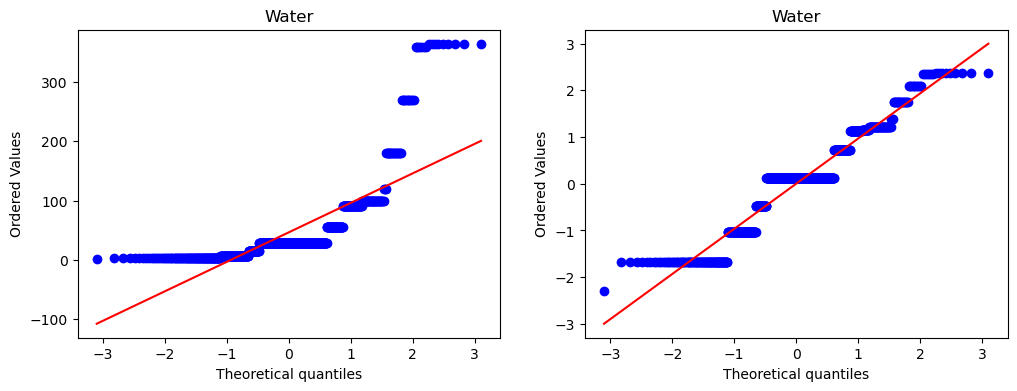

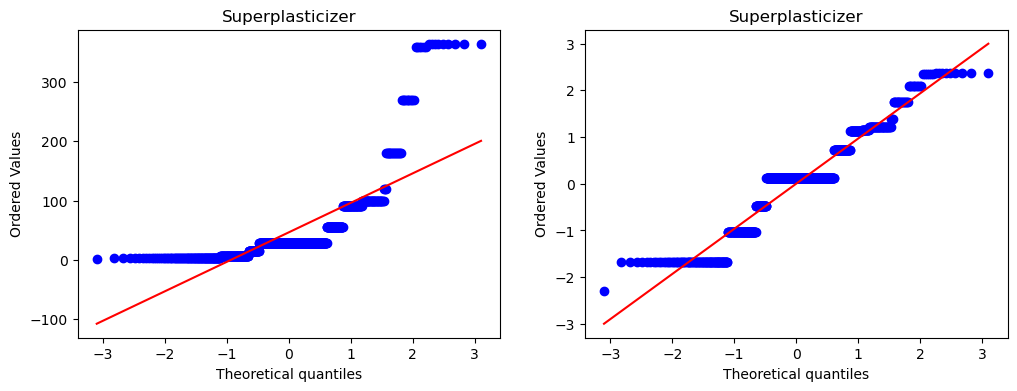

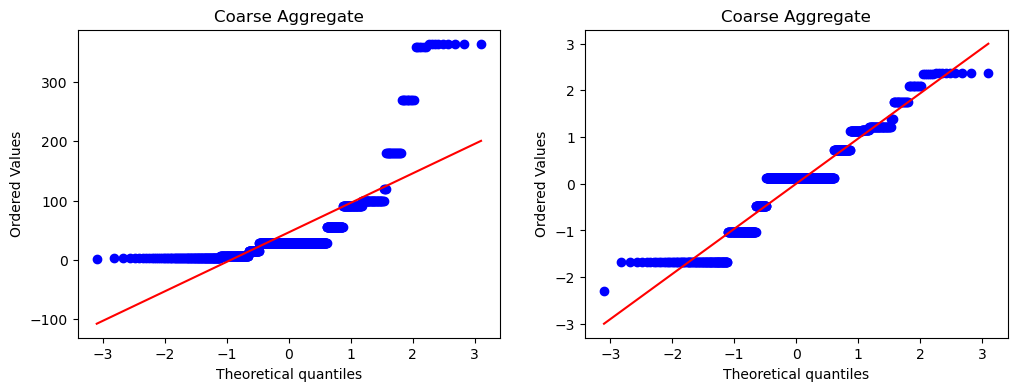

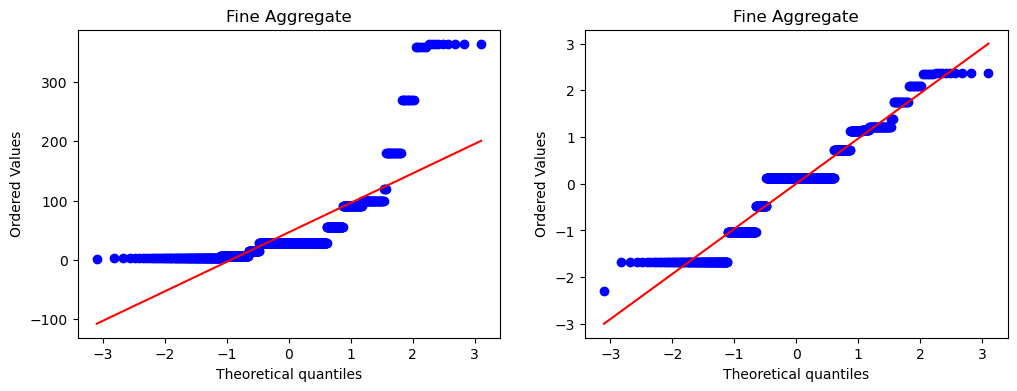

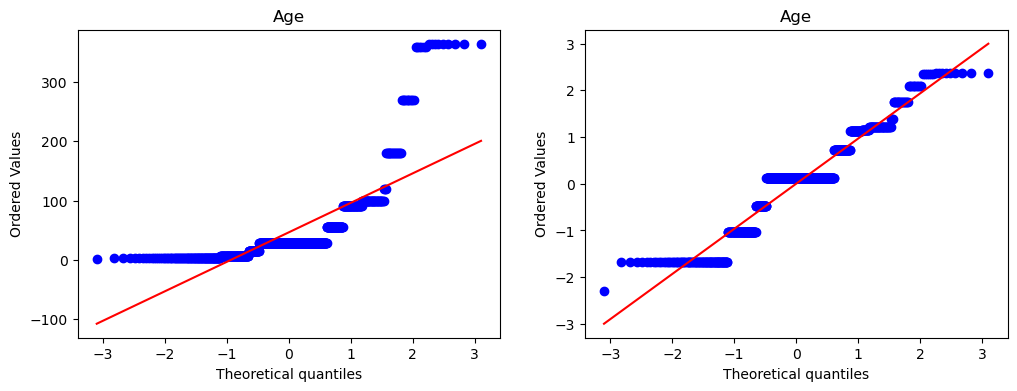

In [18]:
# Analysing Before and After Yeo-Johnson Transformation
X_train_yeo = pd.DataFrame(X_train_yeo, columns=X_train.columns)

for cols in X_train.columns:
    pyplot.figure(figsize=(12,4))
    pyplot.subplot(121)
    stats.probplot(x=X_train[col], dist='norm', plot=pyplot)
    pyplot.title(cols)
   
    pyplot.subplot(122)
    stats.probplot(x=X_train_yeo[col], dist='norm', plot=pyplot)
    pyplot.title(cols)
    pyplot.show()

<h2 style="color:blue">Lambdas Comparison</h2>

In [19]:
# Side by side Box-Cox and Yeo-Johnson Lambdas comparison
pd.DataFrame({'cols':X_train.columns, 'Box-Cox Lambdas':pt.lambdas_, 'Yeo-Johnson Lambdas':pt2.lambdas_})

,cols,Box-Cox Lambdas,Yeo-Johnson Lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.025273,0.016633
2,Fly Ash,-0.032412,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.099711,0.264160
5,Coarse Aggregate,1.129168,1.129395
6,Fine Aggregate,1.829625,1.830763
7,Age,0.048975,0.001771
